# MLflow Runs Analyzer (reproducibility tables + plots)
Builds aggregated tables (Baseline Neutral, Baseline Fair, FACTER iter=3) per model/dataset/mode from MLflow runs.

### General Imports and Config

In [4]:
import os
import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

OUTPUT_DIR = Path("mlflow_analysis_output")
OUTPUT_DIR.mkdir(exist_ok=True)

# CONFIG
EXPERIMENT_NAME = "facter-repro"
ITER_REPORT = 3                        # iteration to report on
INCLUDE_PREDICT_MODES = None           # {"open","rank"} or None for all
INCLUDE_DATASETS = None                # {"ml-1m","amazon"} or None for all
INCLUDE_MODELS_SUBSTR = None           # {"llama-3", "mistral"} or None for all
TRACKING_DB = Path("mlflow.db")
TRACKING_MLRUNS = Path("mlruns")

EXCLUDE_RUN_NAME_SUBSTR = set()        # to exclude some runs, I used it for debugging but could be useful for other things

### MLflow & Load Runs

In [2]:
import mlflow

def resolve_tracking_uri() -> str:
    """
    Prefer sqlite tracking if mlflow.db exists; otherwise fall back to file-store mlruns.
    """
    if TRACKING_DB.exists():
        return f"sqlite:///{TRACKING_DB.resolve()}"
    if TRACKING_MLRUNS.exists():
        return str(TRACKING_MLRUNS.resolve())
    raise FileNotFoundError(
        f"Could not find tracking store. Expected {TRACKING_DB} or {TRACKING_MLRUNS}."
    )

tracking_uri = resolve_tracking_uri()
mlflow.set_tracking_uri(tracking_uri)
print("Tracking URI:", tracking_uri)

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if exp is None:
    raise ValueError(f"MLflow experiment not found: {EXPERIMENT_NAME}")

print("Experiment:", exp.name, "| id:", exp.experiment_id)

# Pull all runs in this experiment (pandas DataFrame).
runs_df = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string='attributes.status = "FINISHED"',
    output_format="pandas",
)

print("Loaded runs:", len(runs_df))
runs_df.head(3)

Tracking URI: sqlite:////home/ozzy/Desktop/facter-repr/mlflow.db


2026/01/28 21:40:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/28 21:40:08 INFO mlflow.store.db.utils: Updating database tables
2026/01/28 21:40:08 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/28 21:40:08 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/28 21:40:08 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/28 21:40:08 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Experiment: facter-repro | id: 1
Loaded runs: 28


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.iter2.SNSV,metrics.baseline_neutral.SNSR.gender,metrics.baseline_fair.NDCG_10,metrics.baseline_neutral.n_violations,...,tags.git.commit,tags.mlflow.user,tags.platform,tags.dataset,tags.model_id,tags.mlflow.runName,tags.python,tags.mlflow.source.type,tags.mlflow.source.name,tags.git.state
0,0266519be494477c8bac7b275444342c,1,FINISHED,file:///gpfs/home4/scur0063/facter-repr/mlruns...,2026-01-28 15:26:41.243000+00:00,2026-01-28 17:49:33.818000+00:00,0.000000,0.023009,0.004546,108.0,...,89db3135e1203a4b97ecfdc94cd7623bc78fa28e,scur0063,Linux-5.14.0-570.76.1.el9_6.x86_64-x86_64-with...,amazon,meta-llama/Meta-Llama-3-8B-Instruct,amazon_meta-llama/Meta-Llama-3-8B-Instruct_see...,3.11.14,LOCAL,scripts/run_facter.py,dirty
1,88667f8b7aaa4ee4aacca2a19911a32b,1,FINISHED,file:///gpfs/home4/scur0063/facter-repr/mlruns...,2026-01-28 12:43:57.560000+00:00,2026-01-28 12:59:42.209000+00:00,0.019741,0.004050,0.454975,60.0,...,89db3135e1203a4b97ecfdc94cd7623bc78fa28e,scur0063,Linux-5.14.0-570.76.1.el9_6.x86_64-x86_64-with...,ml-1m,meta-llama/Meta-Llama-3-8B-Instruct,ml-1m_meta-llama/Meta-Llama-3-8B-Instruct_seed...,3.11.14,LOCAL,scripts/run_facter.py,dirty
2,927cf28d77a94d95a9ac828e2fc8b730,1,FINISHED,file:///gpfs/home4/scur0063/facter-repr/mlruns...,2026-01-28 12:18:28.048000+00:00,2026-01-28 15:43:04.184000+00:00,0.026805,0.024676,0.032747,46.0,...,89db3135e1203a4b97ecfdc94cd7623bc78fa28e,scur0063,Linux-5.14.0-570.76.1.el9_6.x86_64-x86_64-with...,ml-1m,meta-llama/Meta-Llama-3-8B-Instruct,ml-1m_meta-llama/Meta-Llama-3-8B-Instruct_seed...,3.11.14,LOCAL,scripts/run_facter.py,dirty


### Filter Runs

In [5]:
def norm(s: str) -> str:
    return str(s).strip().lower()

def keep_row(row: pd.Series) -> bool:
    # params are in columns like "params.model_id"
    model_id = norm(row.get("params.model_id", ""))
    dataset = norm(row.get("params.dataset", ""))
    predict_mode = norm(row.get("params.predict_mode", ""))

    run_name = norm(row.get("tags.mlflow.runName", ""))  # MLflow standard tag

    # Exclude obvious tests/debug
    if EXCLUDE_RUN_NAME_SUBSTR:
        for bad in EXCLUDE_RUN_NAME_SUBSTR:
            if bad in run_name:
                return False

    if INCLUDE_PREDICT_MODES is not None and predict_mode not in {norm(x) for x in INCLUDE_PREDICT_MODES}:
        return False
    if INCLUDE_DATASETS is not None and dataset not in {norm(x) for x in INCLUDE_DATASETS}:
        return False
    if INCLUDE_MODELS_SUBSTR is not None:
        ok = any(sub in model_id for sub in {norm(x) for x in INCLUDE_MODELS_SUBSTR})
        if not ok:
            return False

    return True

runs_df = runs_df[runs_df.apply(keep_row, axis=1)].reset_index(drop=True)
print("Runs after filters:", len(runs_df))

# Quick provenance view
prov_cols = [
    "run_id",
    "params.dataset",
    "params.model_id",
    "params.predict_mode",
    "params.seed",
    "params.k",
    "params.alpha",
    "params.lambda_fairness",
    "params.tau_rho",
    "params.gamma",
    "params.max_iterations",
    "start_time",
]
display(runs_df[[c for c in prov_cols if c in runs_df.columns]].head(10))

Runs after filters: 28


,run_id,params.dataset,params.model_id,params.predict_mode,params.seed,params.k,params.alpha,params.lambda_fairness,params.tau_rho,params.gamma,params.max_iterations,start_time
0,0266519be494477c8bac7b275444342c,amazon,meta-llama/Meta-Llama-3-8B-Instruct,open,131932,10,0.1,0.7,0.9,0.95,3,2026-01-28 15:26:41.243000+00:00
1,88667f8b7aaa4ee4aacca2a19911a32b,ml-1m,meta-llama/Meta-Llama-3-8B-Instruct,rank,671155,10,0.1,0.7,0.9,0.95,3,2026-01-28 12:43:57.560000+00:00
2,927cf28d77a94d95a9ac828e2fc8b730,ml-1m,meta-llama/Meta-Llama-3-8B-Instruct,open,131932,10,0.1,0.7,0.9,0.95,3,2026-01-28 12:18:28.048000+00:00
3,9cee2ee3f4e94ca0aa4606a32e2ab207,ml-1m,meta-llama/Llama-2-7b-chat-hf,rank,671155,10,0.1,0.7,0.9,0.95,3,2026-01-27 18:02:30.203000+00:00
4,bde284c7dc9e45f78fce858c2a94ec4a,ml-1m,meta-llama/Llama-2-7b-chat-hf,rank,131932,10,0.1,0.7,0.9,0.95,3,2026-01-27 18:02:29.959000+00:00
5,d5e96806b1cc41ad9b7de840e21b3a0e,ml-1m,meta-llama/Llama-2-7b-chat-hf,open,131932,10,0.1,0.7,0.9,0.95,3,2026-01-27 17:45:01.105000+00:00
6,74831232a3f14f25b62cecceeba0c801,ml-1m,meta-llama/Llama-2-7b-chat-hf,open,671155,10,0.1,0.7,0.9,0.95,3,2026-01-27 17:41:33.514000+00:00
7,31ca9cba8c054f2588cb8881c1c7393e,ml-1m,mistralai/Mistral-7B-Instruct-v0.2,open,131932,10,0.1,0.7,0.9,0.95,3,2026-01-27 17:32:30.261000+00:00
8,d7eb3b117b484236b8b421559efcca06,ml-1m,mistralai/Mistral-7B-Instruct-v0.2,rank,671155,10,0.1,0.7,0.9,0.95,3,2026-01-27 17:31:32.331000+00:00
9,c332cadb09e2479c94287be997a34ea5,ml-1m,mistralai/Mistral-7B-Instruct-v0.2,open,671155,10,0.1,0.7,0.9,0.95,3,2026-01-27 17:31:23.971000+00:00


### Metrics & Helpers

In [6]:
def first_present(row: pd.Series, keys: List[str]) -> float:
    """
    Return the first metric value present (not NaN) among `keys`.
    Keys should be full MLflow columns like "metrics.baseline_neutral.Recall@10".
    """
    for k in keys:
        if k in row.index and pd.notna(row[k]):
            return float(row[k])
    return np.nan

def metric_col(name: str) -> str:
    return f"metrics.{name}"

# Baseline metrics are logged as: metrics.baseline_neutral.<k> and metrics.baseline_fair.<k>
# FACTER metrics are logged as: metrics.iter3.<k>
K = int(runs_df["params.k"].dropna().astype(int).iloc[0]) if "params.k" in runs_df.columns and len(runs_df) else 10

BASE_NEUTRAL_PREFIX = "baseline_neutral"
BASE_FAIR_PREFIX = "baseline_fair"

def baseline_key(prefix: str, key: str) -> str:
    return metric_col(f"{prefix}.{key}")

def iter_key(it: int, key: str) -> str:
    return metric_col(f"iter{it}.{key}")

UTILITY_KEYS = {
    "recall_single": [
        baseline_key("{prefix}", f"Recall@{K}.single"),
        baseline_key("{prefix}", f"Recall{K}.single"),
        baseline_key("{prefix}", f"Recall@{K}"),
        baseline_key("{prefix}", f"Recall{K}"),
    ],
    "ndcg_single": [
        baseline_key("{prefix}", f"NDCG@{K}.single"),
        baseline_key("{prefix}", f"NDCG{K}.single"),
        baseline_key("{prefix}", f"NDCG@{K}"),
        baseline_key("{prefix}", f"NDCG{K}"),
    ],
    "recall_multi": [
        baseline_key("{prefix}", f"Recall@{K}.multi"),
        baseline_key("{prefix}", f"Recall{K}.multi"),
    ],
    "ndcg_multi": [
        baseline_key("{prefix}", f"NDCG@{K}.multi"),
        baseline_key("{prefix}", f"NDCG{K}.multi"),
    ],
}

FAIRNESS_KEYS = {
    "SNSR": [
        baseline_key("{prefix}", "SNSR"),
    ],
    "SNSV": [
        baseline_key("{prefix}", "SNSV"),
    ],
    "CFR_all": [
        baseline_key("{prefix}", "CFR_all"),
        baseline_key("{prefix}", "CFR"),
    ],
}

VIOL_KEYS = {
    "base_n_viol": [
        baseline_key("{prefix}", "n_violations"),
    ],
    "facter_viol_dyn": [
        iter_key(ITER_REPORT, "violations"),
    ],
    "facter_viol_fixedQ0": [
        iter_key(ITER_REPORT, "violations.fixedQ0"),
        iter_key(ITER_REPORT, "violations.fixedQ0.corrected"),
        iter_key(ITER_REPORT, "fixedQ0_corrected_violations"),
    ],
    "facter_viol_fixedQstar": [
        iter_key(ITER_REPORT, "violations.fixedQstar"),
        iter_key(ITER_REPORT, "fixedQstar_violations"),
    ],
}

def resolve_keys_for_prefix(keys: List[str], prefix: str) -> List[str]:
    # Replace "{prefix}" placeholders
    return [k.replace("{prefix}", prefix) for k in keys]

### Build Table

In [7]:
def build_long_rows(runs: pd.DataFrame) -> pd.DataFrame:
    records = []

    for _, row in runs.iterrows():
        model_id = row.get("params.model_id", "Unknown")
        dataset = row.get("params.dataset", "Unknown")
        predict_mode = row.get("params.predict_mode", "Unknown")
        seed = row.get("params.seed", np.nan)
        run_id = row.get("run_id")

        def add_baseline(prefix: str, label: str):
            rec = {
                "variant": label,
                "run_id": run_id,
                "model_id": model_id,
                "dataset": dataset,
                "predict_mode": predict_mode,
                "seed": seed,
            }
            # utility
            for out_name, keys in UTILITY_KEYS.items():
                rec[out_name] = first_present(row, resolve_keys_for_prefix(keys, prefix))
            # fairness
            for out_name, keys in FAIRNESS_KEYS.items():
                rec[out_name] = first_present(row, resolve_keys_for_prefix(keys, prefix))
            # violations
            rec["n_violations"] = first_present(row, resolve_keys_for_prefix(VIOL_KEYS["base_n_viol"], prefix))
            records.append(rec)

        add_baseline(BASE_NEUTRAL_PREFIX, "Baseline Neutral")
        add_baseline(BASE_FAIR_PREFIX, "Baseline Fair")

        # FACTER (iteration report)
        rec_f = {
            "variant": f"FACTER (iter={ITER_REPORT})",
            "run_id": run_id,
            "model_id": model_id,
            "dataset": dataset,
            "predict_mode": predict_mode,
            "seed": seed,
        }
        # utility for iter
        for out_name in ["recall_single", "ndcg_single", "recall_multi", "ndcg_multi"]:
            # convert baseline keys to iter keys: replace metrics.baseline_*.<metric> with metrics.iter3.<metric-name>
            # Here we just try common iter metric names you likely log: "Recall10", "NDCG10", etc.
            if out_name.startswith("recall"):
                rec_f[out_name] = first_present(row, [iter_key(ITER_REPORT, f"Recall{K}"), iter_key(ITER_REPORT, f"Recall@{K}")])
            else:
                rec_f[out_name] = first_present(row, [iter_key(ITER_REPORT, f"NDCG{K}"), iter_key(ITER_REPORT, f"NDCG@{K}")])

        # fairness for iter
        rec_f["SNSR"] = first_present(row, [iter_key(ITER_REPORT, "SNSR")])
        rec_f["SNSV"] = first_present(row, [iter_key(ITER_REPORT, "SNSV")])
        rec_f["CFR_all"] = first_present(row, [iter_key(ITER_REPORT, "CFR_all"), iter_key(ITER_REPORT, "CFR")])

        # violations for iter
        rec_f["n_violations"] = first_present(row, VIOL_KEYS["facter_viol_dyn"])
        rec_f["viol_fixedQ0"] = first_present(row, VIOL_KEYS["facter_viol_fixedQ0"])
        rec_f["viol_fixedQstar"] = first_present(row, VIOL_KEYS["facter_viol_fixedQstar"])

        records.append(rec_f)

    return pd.DataFrame(records)

long_df = build_long_rows(runs_df)
print("long_df rows:", len(long_df))
display(long_df.head(9))

long_df rows: 84


,variant,run_id,model_id,dataset,predict_mode,seed,recall_single,ndcg_single,recall_multi,ndcg_multi,SNSR,SNSV,CFR_all,n_violations,viol_fixedQ0,viol_fixedQstar
0,Baseline Neutral,0266519be494477c8bac7b275444342c,meta-llama/Meta-Llama-3-8B-Instruct,amazon,open,131932,NaN,NaN,NaN,NaN,0.000000,0.000000,0.858280,108.0,NaN,NaN
1,Baseline Fair,0266519be494477c8bac7b275444342c,meta-llama/Meta-Llama-3-8B-Instruct,amazon,open,131932,NaN,NaN,NaN,NaN,0.000000,0.000000,0.900559,101.0,NaN,NaN
2,FACTER (iter=3),0266519be494477c8bac7b275444342c,meta-llama/Meta-Llama-3-8B-Instruct,amazon,open,131932,0.003040,0.002871,0.003040,0.002871,0.000000,0.000000,NaN,5.0,123.0,2.0
3,Baseline Neutral,88667f8b7aaa4ee4aacca2a19911a32b,meta-llama/Meta-Llama-3-8B-Instruct,ml-1m,rank,671155,NaN,NaN,NaN,NaN,0.026860,0.026860,0.527091,60.0,NaN,NaN
4,Baseline Fair,88667f8b7aaa4ee4aacca2a19911a32b,meta-llama/Meta-Llama-3-8B-Instruct,ml-1m,rank,671155,NaN,NaN,NaN,NaN,0.019805,0.019805,0.528819,59.0,NaN,NaN
5,FACTER (iter=3),88667f8b7aaa4ee4aacca2a19911a32b,meta-llama/Meta-Llama-3-8B-Instruct,ml-1m,rank,671155,0.401739,0.435780,0.401739,0.435780,0.025360,0.025360,NaN,8.0,72.0,5.0
6,Baseline Neutral,927cf28d77a94d95a9ac828e2fc8b730,meta-llama/Meta-Llama-3-8B-Instruct,ml-1m,open,131932,NaN,NaN,NaN,NaN,0.027332,0.027332,0.660312,46.0,NaN,NaN
7,Baseline Fair,927cf28d77a94d95a9ac828e2fc8b730,meta-llama/Meta-Llama-3-8B-Instruct,ml-1m,open,131932,NaN,NaN,NaN,NaN,0.041181,0.041181,0.678319,44.0,NaN,NaN
8,FACTER (iter=3),927cf28d77a94d95a9ac828e2fc8b730,meta-llama/Meta-Llama-3-8B-Instruct,ml-1m,open,131932,0.025619,0.029686,0.025619,0.029686,0.034358,0.034358,NaN,9.0,55.0,8.0


### Aggregate

In [8]:
METRICS_OUT = [
    "recall_single", "ndcg_single",
    "recall_multi", "ndcg_multi",
    "SNSR", "SNSV", "CFR_all",
    "n_violations", "viol_fixedQ0", "viol_fixedQstar"
]

group_cols = ["model_id", "dataset", "predict_mode"]

agg_rows = []
for combo, g in long_df.groupby(group_cols):
    for variant, gv in g.groupby("variant"):
        rec = {
            "model_id": combo[0],
            "dataset": combo[1],
            "predict_mode": combo[2],
            "variant": variant,
            "num_runs": int(gv["run_id"].nunique()),
        }
        for m in METRICS_OUT:
            rec[f"{m}_mean"] = float(np.nanmean(gv[m].to_numpy(dtype=float)))
            rec[f"{m}_std"]  = float(np.nanstd(gv[m].to_numpy(dtype=float), ddof=1)) if gv[m].count() >= 2 else np.nan
        agg_rows.append(rec)

agg_df = pd.DataFrame(agg_rows)

# Export per-combo CSVs + combined
for combo, g in agg_df.groupby(group_cols):
    safe = f"{combo[0]}__{combo[1]}__{combo[2]}".replace("/", "-").replace(" ", "_")
    path = OUTPUT_DIR / f"agg_3row__{safe}.csv"
    g.sort_values("variant").to_csv(path, index=False)

all_path = OUTPUT_DIR / "agg_3row_all.csv"
agg_df.to_csv(all_path, index=False)

print("✓ Wrote:", all_path)
display(agg_df.sort_values(group_cols + ["variant"]).head(12))

✓ Wrote: mlflow_analysis_output/agg_3row_all.csv


/tmp/ipykernel_50736/1108852200.py:21: RuntimeWarning: Mean of empty slice
  rec[f"{m}_mean"] = float(np.nanmean(gv[m].to_numpy(dtype=float)))
/tmp/ipykernel_50736/1108852200.py:21: RuntimeWarning: Mean of empty slice
  rec[f"{m}_mean"] = float(np.nanmean(gv[m].to_numpy(dtype=float)))
/tmp/ipykernel_50736/1108852200.py:21: RuntimeWarning: Mean of empty slice
  rec[f"{m}_mean"] = float(np.nanmean(gv[m].to_numpy(dtype=float)))
/tmp/ipykernel_50736/1108852200.py:21: RuntimeWarning: Mean of empty slice
  rec[f"{m}_mean"] = float(np.nanmean(gv[m].to_numpy(dtype=float)))
/tmp/ipykernel_50736/1108852200.py:21: RuntimeWarning: Mean of empty slice
  rec[f"{m}_mean"] = float(np.nanmean(gv[m].to_numpy(dtype=float)))
/tmp/ipykernel_50736/1108852200.py:21: RuntimeWarning: Mean of empty slice
  rec[f"{m}_mean"] = float(np.nanmean(gv[m].to_numpy(dtype=float)))
/tmp/ipykernel_50736/1108852200.py:21: RuntimeWarning: Mean of empty slice
  rec[f"{m}_mean"] = float(np.nanmean(gv[m].to_numpy(dtype=float)))

,model_id,dataset,predict_mode,variant,num_runs,recall_single_mean,recall_single_std,ndcg_single_mean,ndcg_single_std,recall_multi_mean,...,SNSV_mean,SNSV_std,CFR_all_mean,CFR_all_std,n_violations_mean,n_violations_std,viol_fixedQ0_mean,viol_fixedQ0_std,viol_fixedQstar_mean,viol_fixedQstar_std
0,meta-llama/Llama-2-7b-chat-hf,ml-1m,open,Baseline Fair,3,NaN,NaN,NaN,NaN,NaN,...,0.020885,0.004384,0.727802,0.015805,55.000000,2.000000,NaN,NaN,NaN,NaN
1,meta-llama/Llama-2-7b-chat-hf,ml-1m,open,Baseline Neutral,3,NaN,NaN,NaN,NaN,NaN,...,0.016708,0.001982,0.640258,0.003575,45.333333,9.073772,NaN,NaN,NaN,NaN
2,meta-llama/Llama-2-7b-chat-hf,ml-1m,open,FACTER (iter=3),3,0.019973,0.002144,0.022194,0.002258,0.019973,...,0.023020,0.007964,NaN,NaN,8.333333,0.577350,78.333333,8.326664,7.333333,0.577350
3,meta-llama/Llama-2-7b-chat-hf,ml-1m,rank,Baseline Fair,3,NaN,NaN,NaN,NaN,NaN,...,0.015331,0.000326,0.494089,0.031454,59.000000,3.605551,NaN,NaN,NaN,NaN
4,meta-llama/Llama-2-7b-chat-hf,ml-1m,rank,Baseline Neutral,3,NaN,NaN,NaN,NaN,NaN,...,0.017426,0.002495,0.496964,0.003799,60.666667,6.350853,NaN,NaN,NaN,NaN
5,meta-llama/Llama-2-7b-chat-hf,ml-1m,rank,FACTER (iter=3),3,0.317031,0.003227,0.325547,0.002710,0.317031,...,0.016669,0.002583,NaN,NaN,7.666667,0.577350,79.333333,8.504901,7.000000,1.000000
6,meta-llama/Meta-Llama-3-8B-Instruct,amazon,open,Baseline Fair,3,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.906426,0.022610,91.333333,8.386497,NaN,NaN,NaN,NaN
7,meta-llama/Meta-Llama-3-8B-Instruct,amazon,open,Baseline Neutral,3,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.879049,0.018015,107.666667,1.527525,NaN,NaN,NaN,NaN
8,meta-llama/Meta-Llama-3-8B-Instruct,amazon,open,FACTER (iter=3),3,0.003418,0.000344,0.003492,0.000555,0.003418,...,0.000000,0.000000,NaN,NaN,3.000000,1.732051,118.000000,10.440307,2.000000,0.000000
9,meta-llama/Meta-Llama-3-8B-Instruct,amazon,rank,Baseline Fair,3,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.681309,0.012187,91.333333,3.214550,NaN,NaN,NaN,NaN


### Plot

✓ Saved: mlflow_analysis_output/violations_dyn__ml-1m__open.png


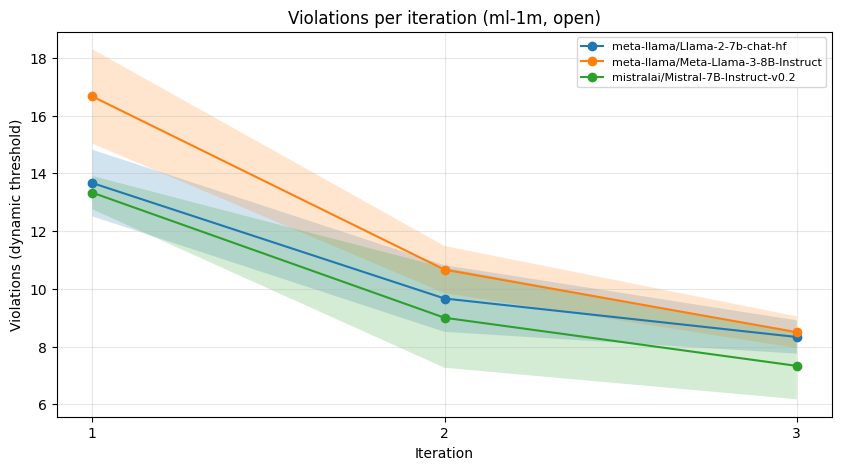

In [9]:
def plot_violations_over_iters(runs: pd.DataFrame, dataset_filter="ml-1m", mode_filter="open"):
    iters = [1, 2, 3]
    rows = []

    for _, r in runs.iterrows():
        ds = norm(r.get("params.dataset", ""))
        pm = norm(r.get("params.predict_mode", ""))
        if ds != norm(dataset_filter) or pm != norm(mode_filter):
            continue

        mid = str(r.get("params.model_id", ""))
        for t in iters:
            v = first_present(r, [iter_key(t, "violations")])
            if pd.notna(v):
                rows.append({"model_id": mid, "iter": t, "violations": v, "run_id": r["run_id"]})

    if not rows:
        print("No data for plot.")
        return

    dfp = pd.DataFrame(rows)
    # aggregate
    g = dfp.groupby(["model_id", "iter"])["violations"].agg(["mean", "std", "count"]).reset_index()

    plt.figure()
    for model_id, gm in g.groupby("model_id"):
        plt.plot(gm["iter"], gm["mean"], marker="o", label=model_id)
        if gm["std"].notna().any():
            plt.fill_between(gm["iter"], gm["mean"] - gm["std"], gm["mean"] + gm["std"], alpha=0.2)

    plt.xlabel("Iteration")
    plt.ylabel("Violations (dynamic threshold)")
    plt.title(f"Violations per iteration ({dataset_filter}, {mode_filter})")
    plt.xticks(iters)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    out = OUTPUT_DIR / f"violations_dyn__{dataset_filter}__{mode_filter}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    print("✓ Saved:", out)
    plt.show()

plot_violations_over_iters(runs_df, dataset_filter="ml-1m", mode_filter="open")

### Emissions

In [ ]:
emissions_path = Path("emissions")
if not emissions_path.exists():
    emissions_path = Path("./facter-repr/emissions")

if not emissions_path.exists():
    print(f"Emissions folder not found at {emissions_path.resolve()}")
else:
    files = sorted(emissions_path.glob("*.csv"))
    if not files:
        print("No emissions CSV files found.")
    else:
        dfs = []
        for f in files:
            try:
                dfs.append(pd.read_csv(f))
            except Exception as e:
                print("Failed reading", f, e)
        if not dfs:
            print("No readable emissions files.")
        else:
            em = pd.concat(dfs, ignore_index=True)

            def safe_sum(col):
                return float(em[col].sum()) if col in em.columns else 0.0
            def safe_mean(col):
                return float(em[col].mean()) if col in em.columns else np.nan

            total_duration = safe_sum("duration")
            total_emissions = safe_sum("emissions")
            total_energy = safe_sum("energy_consumed")

            print("=== Emissions (aggregate; not joined to run_id unless logged) ===")
            print(f"Files: {len(files)}")
            print(f"Total duration (s): {total_duration:.2f} ({total_duration/3600:.2f} h)")
            print(f"Total emissions (kg CO2): {total_emissions:.6f}")
            print(f"Total energy (kWh): {total_energy:.6f}")
            print(f"Avg duration (s): {safe_mean('duration'):.2f}")
            print(f"Avg emissions (kg CO2): {safe_mean('emissions'):.6f}")
            print(f"Avg energy (kWh): {safe_mean('energy_consumed'):.6f}")

            out = OUTPUT_DIR / "emissions_summary.csv"
            pd.DataFrame({
                "metric": [
                    "num_files", "total_duration_seconds", "total_duration_hours",
                    "total_emissions_kgco2", "total_energy_kwh",
                    "avg_duration_seconds", "avg_emissions_kgco2", "avg_energy_kwh"
                ],
                "value": [
                    len(files), total_duration, total_duration/3600,
                    total_emissions, total_energy,
                    safe_mean("duration"), safe_mean("emissions"), safe_mean("energy_consumed")
                ]
            }).to_csv(out, index=False)
            print("✓ Saved:", out)